# Transforming Shapes with Matrices

## Purpose

Apply matrix transformations to many points at once.

So far, we have transformed individual vectors.

A shape can be represented as a collection of points. If we transform each point, we transform the whole shape.

## Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-5, 5), ylim=(-5, 5), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_transformation(ax, original, transformed, original_label="v", transformed_label="A @ v"):
    draw_vector(ax, original, label=original_label, label_offset=(0.1, 0.1))
    draw_vector(ax, transformed, label=transformed_label, label_offset=(0.1, -0.35), width=0.01)


def plot_shape(ax, points, label=None, close=True, marker="o"):
    points = np.array(points, dtype=float)
    plot_points = points

    if close:
        plot_points = np.vstack([points, points[0]])

    ax.plot(plot_points[:, 0], plot_points[:, 1], marker=marker)

    if label:
        centre = points.mean(axis=0)
        ax.text(centre[0], centre[1], label, fontsize=10)


def transform_points(A, points):
    points = np.array(points, dtype=float)
    return points @ A.T

## Representing a shape as points

Here is a simple square represented by its corner points:

$$
(0, 0), (1, 0), (1, 1), (0, 1)
$$

In [2]:
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
])

print(square)

[[0 0]
 [1 0]
 [1 1]
 [0 1]]


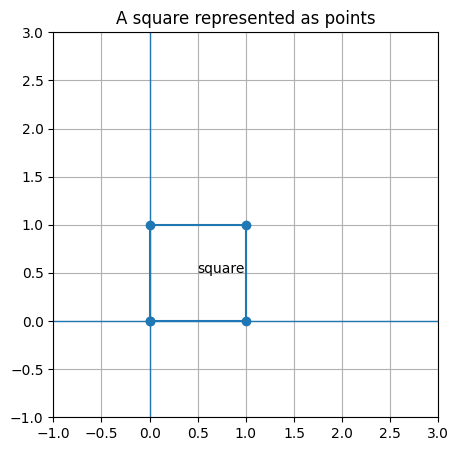

In [3]:
fig, ax = setup_vector_plot(xlim=(-1, 3), ylim=(-1, 3), figsize=(5, 5))

plot_shape(ax, square, label="square")

ax.set_title("A square represented as points")
plt.show()

The square is just data: one row per point, two columns for x and y.

## Applying a matrix to every point

Use a scaling matrix:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

This doubles x-values and leaves y-values unchanged.

In [4]:
A = np.array([
    [2, 0],
    [0, 1],
])

transformed_square = transform_points(A, square)

print(transformed_square)

[[0. 0.]
 [2. 0.]
 [2. 1.]
 [0. 1.]]


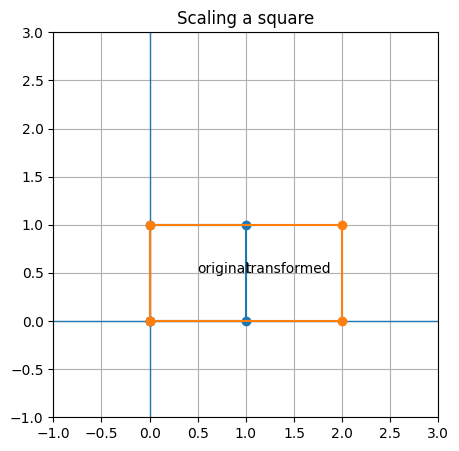

In [5]:
fig, ax = setup_vector_plot(xlim=(-1, 3), ylim=(-1, 3), figsize=(5, 5))

plot_shape(ax, square, label="original")
plot_shape(ax, transformed_square, label="transformed")

ax.set_title("Scaling a square")
plt.show()

The square has become a rectangle.

The transformation was applied to every point.

## Shearing a shape

A shear slants the shape.

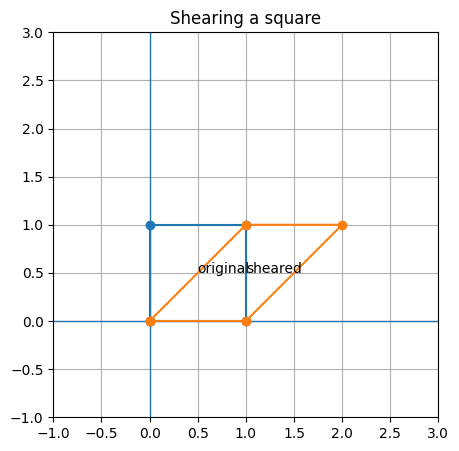

In [6]:
A = np.array([
    [1, 1],
    [0, 1],
])

sheared_square = transform_points(A, square)

fig, ax = setup_vector_plot(xlim=(-1, 3), ylim=(-1, 3), figsize=(5, 5))

plot_shape(ax, square, label="original")
plot_shape(ax, sheared_square, label="sheared")

ax.set_title("Shearing a square")
plt.show()

The square becomes a slanted parallelogram.

## Rotating a shape

A rotation matrix can rotate every point in the shape.

For example, rotate the square by 45 degrees.

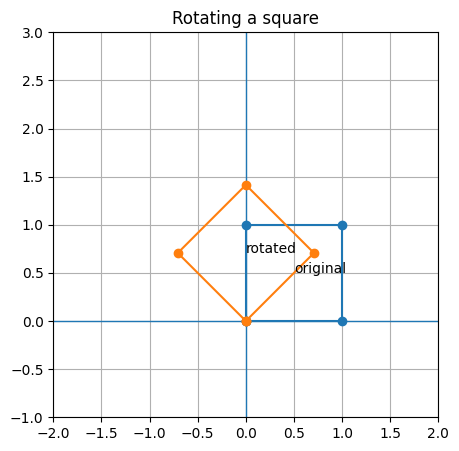

In [7]:
def rotation_matrix_degrees(degrees):
    theta = np.deg2rad(degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

A = rotation_matrix_degrees(45)

rotated_square = transform_points(A, square)

fig, ax = setup_vector_plot(xlim=(-2, 2), ylim=(-1, 3), figsize=(5, 5))

plot_shape(ax, square, label="original")
plot_shape(ax, rotated_square, label="rotated")

ax.set_title("Rotating a square")
plt.show()

The square rotates around the origin because the matrix transformation is applied relative to the origin.

## Why position relative to the origin matters

If a shape is not centred around the origin, rotation can make it appear to swing around the origin.

To rotate around the shape's own centre, we would usually:

1. move the shape so its centre is at the origin
2. rotate it
3. move it back

That involves translation, which is not represented by a plain 2×2 matrix in this simple setup.

## Applying several transformations

Matrix transformations can be composed.

For example, we can shear and then rotate.

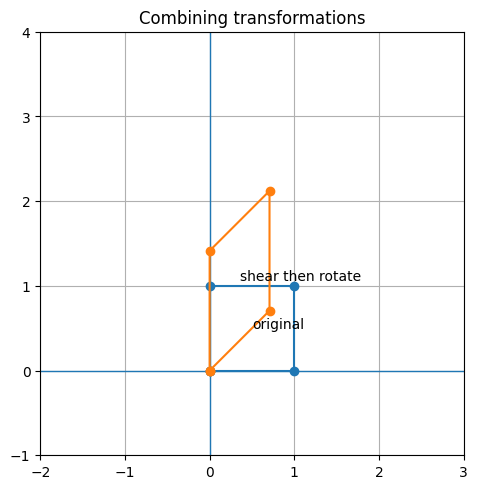

In [8]:
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
])

shear = np.array([
    [1, 1],
    [0, 1],
])

rotate = rotation_matrix_degrees(45)

sheared_then_rotated = transform_points(rotate, transform_points(shear, square))

fig, ax = setup_vector_plot(xlim=(-2, 3), ylim=(-1, 4), figsize=(5.5, 5.5))

plot_shape(ax, square, label="original")
plot_shape(ax, sheared_then_rotated, label="shear then rotate")

ax.set_title("Combining transformations")
plt.show()

The order matters.

Applying shear then rotation is not necessarily the same as applying rotation then shear.

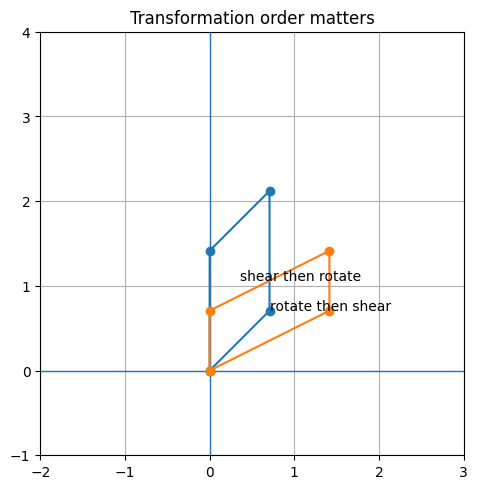

In [9]:
rotate_then_sheared = transform_points(shear, transform_points(rotate, square))

fig, ax = setup_vector_plot(xlim=(-2, 3), ylim=(-1, 4), figsize=(5.5, 5.5))

plot_shape(ax, sheared_then_rotated, label="shear then rotate")
plot_shape(ax, rotate_then_sheared, label="rotate then shear")

ax.set_title("Transformation order matters")
plt.show()

## Why this matters

Many data-processing and machine-learning operations can be viewed as transformations.

The objects may not be literal 2D shapes, but the idea is similar:

- data is represented numerically
- matrices transform that data
- transformations can be composed
- the order of transformations can matter

## Summary

- A shape can be represented as a collection of points.
- Applying a matrix to every point transforms the shape.
- Scaling, shear and rotation can all be visualised this way.
- Rotation happens around the origin in this simple setup.
- Transformation order matters.

## Next step

Next, we will return to projections and use them as motivation for least squares.